# Notebook Objective

# 05 Model Training and Evaluation

This notebook trains and evaluates RUL prediction models using the engineered window features from Notebook 04.

The main objectives are:

- train simple baseline models for comparison
- train classical machine learning regressors on tabular window features
- train a GRU sequence model on raw sliding-window sensor streams
- evaluate models using MAE, RMSE and an asymmetric prognostics score
- compare model performance on the validation set
- analyze prediction errors across the engine lifetime
- prepare the best-performing model for later explainability and maintenance simulation

This notebook compares handcrafted-feature tree models with a raw-window GRU sequence model to assess whether deep learning improves predictive performance enough to justify its added complexity.

# Imports and Project Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression


In [3]:
from src.data_loading import DATASET_IDS
from src.config import load_config, flatten_config
from src.pipeline import recreate_prediction_pipeline
from src.models import (
    build_gru_sequence_model,
    build_random_forest_model,
    build_xgboost_model,
    create_sequence_dataloaders,
    get_torch_device,
    predict_sequence_model,
    train_gru_sequence_model,
)


# Load and Prepare Feature Data

The selected C-MAPSS subset is loaded, preprocessed and transformed into tabular window features using the same workflow as in the previous notebooks. This keeps the model training notebook reproducible and independent of notebook kernel state.

In [4]:
config = load_config()
flat_config = flatten_config(config)

CURRENT_DATASET = flat_config["CURRENT_DATASET"]
RUL_CAP = flat_config["RUL_CAP"]
VALIDATION_SIZE = flat_config["VALIDATION_SIZE"]
RANDOM_STATE = flat_config["RANDOM_STATE"]
WINDOW_SIZE = flat_config["WINDOW_SIZE"]
WINDOW_STEP = flat_config["WINDOW_STEP"]

index_cols = flat_config["INDEX_COLS"]
target_cols = flat_config["TARGET_COLS"]
helper_cols = flat_config["HELPER_COLS"]
target_col = flat_config["TARGET_COL"]

model_config = config["models"]
sequence_model_config = model_config["gru_sequence"]
conformal_config = config["conformal"]
simulation_config = config["simulation"]

if CURRENT_DATASET not in DATASET_IDS:
    raise ValueError(f"Unknown dataset: {CURRENT_DATASET}")


In [5]:
# Recreate the configured preprocessing and feature engineering pipeline.
pipeline_outputs = recreate_prediction_pipeline(config)
globals().update(pipeline_outputs)


In [6]:
print(f"Current dataset: {CURRENT_DATASET}")
print(f"Input features before window aggregation: {len(feature_cols)}")
print(f"Tabular window features: {len(tabular_feature_cols)}")
print(f"Removed constant features: {len(constant_features)}")

print(f"X_train_tabular shape: {X_train_tabular.shape}")
print(f"y_train_tabular shape: {y_train_tabular.shape}")

print(f"X_val_tabular shape:   {X_val_tabular.shape}")
print(f"y_val_tabular shape:   {y_val_tabular.shape}")

print(f"X_test_tabular shape:  {X_test_tabular.shape}")

Current dataset: FD001
Input features before window aggregation: 17
Tabular window features: 102
Removed constant features: 7
X_train_tabular shape: (14241, 102)
y_train_tabular shape: (14241,)
X_val_tabular shape:   (3490, 102)
y_val_tabular shape:   (3490,)
X_test_tabular shape:  (10196, 102)


In [7]:
# Ensure that every tabular training sample has one target value.
assert X_train_tabular.shape[0] == y_train_tabular.shape[0]

# Ensure that every tabular validation sample has one target value.
assert X_val_tabular.shape[0] == y_val_tabular.shape[0]

# Ensure that train, validation and test use identical tabular feature columns.
assert list(X_train_tabular.columns) == list(X_val_tabular.columns)
assert list(X_train_tabular.columns) == list(X_test_tabular.columns)

# Ensure that train and validation are split by disjoint engine units.
assert set(train_engines).isdisjoint(set(val_engines))

# Evaluation Metrics

The models are evaluated using standard regression metrics and an asymmetric prognostics score. MAE and RMSE measure average prediction error, while the asymmetric score reflects the practical maintenance risk of late predictions.

In [8]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error


def cmapss_score(y_true, y_pred):
    error = y_pred - y_true
    
    score = np.where(
        error < 0,
        np.exp(-error / 13) - 1,
        np.exp(error / 10) - 1
    )
    
    return np.sum(score)

In [9]:
def evaluate_predictions(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "C-MAPSS_score": cmapss_score(y_true, y_pred)
    }

In [10]:
def evaluate_model(model_name, model, X, y_true):
    y_pred = model.predict(X)
    metrics = evaluate_predictions(y_true, y_pred)
    metrics["model"] = model_name
    
    return metrics, y_pred

In [11]:
metric_test_true = np.array([100, 50, 0])
metric_test_pred = np.array([90, 60, 5])

metric_test_results = evaluate_predictions(
    metric_test_true,
    metric_test_pred
)

# Ensure that all expected metric names are returned.
assert set(metric_test_results.keys()) == {"MAE", "RMSE", "C-MAPSS_score"}

# Ensure that metric values are non-negative.
assert all(value >= 0 for value in metric_test_results.values())

metric_test_results

{'MAE': 8.333333333333334,
 'RMSE': 8.660254037844387,
 'C-MAPSS_score': np.float64(3.525108633107619)}

# Age Baseline Model

A simple age-based baseline is trained as a reference point. It uses only the final cycle index of each sliding window and no sensor information. This tests whether the machine-learning models improve beyond the degradation information already implied by engine age.

In [12]:
age_baseline_model = LinearRegression()

age_baseline_model.fit(
    train_window_metadata[["end_cycle"]],
    y_train_tabular
)

age_baseline_val_pred = age_baseline_model.predict(
    val_window_metadata[["end_cycle"]]
)
age_baseline_val_pred = np.clip(
    age_baseline_val_pred,
    0,
    RUL_CAP
)

age_baseline_metrics = evaluate_predictions(
    y_val_tabular,
    age_baseline_val_pred
)
age_baseline_metrics["model"] = "Age baseline"

age_baseline_metrics


{'MAE': 22.727164657505625,
 'RMSE': 27.942080877224246,
 'C-MAPSS_score': np.float64(134393.0083489233),
 'model': 'Age baseline'}

In [13]:
age_baseline_val_pred[:10]


array([124.47198864, 124.01121523, 123.55044181, 123.08966839,
       122.62889497, 122.16812156, 121.70734814, 121.24657472,
       120.78580131, 120.32502789])

In [14]:
# Ensure that the age baseline returns one prediction for every validation sample.
assert age_baseline_val_pred.shape[0] == y_val_tabular.shape[0]

# Ensure that age-baseline predictions are finite and clipped to the target range.
assert np.isfinite(age_baseline_val_pred).all()
assert (age_baseline_val_pred >= 0).all()
assert (age_baseline_val_pred <= RUL_CAP).all()


The age baseline predicts capped RUL from window end cycle only. It is still deliberately simple, but it is more meaningful than a constant prediction because RUL is strongly related to engine age in run-to-failure data.

# Random Forest Regressor

A Random Forest Regressor is trained as the first non-linear machine learning model. It can capture interactions between engineered window features and provides a strong classical baseline for RUL prediction.

In [15]:
rf_model = build_random_forest_model(
    model_config,
    random_state=RANDOM_STATE
)

rf_model.fit(
    X_train_tabular,
    y_train_tabular
)

rf_metrics, rf_val_pred = evaluate_model(
    "Random Forest",
    rf_model,
    X_val_tabular,
    y_val_tabular
)

rf_metrics


{'MAE': 9.347447023733988,
 'RMSE': 12.789989657221456,
 'C-MAPSS_score': np.float64(10533.922377016039),
 'model': 'Random Forest'}

In [16]:
# Ensure that the Random Forest returns one prediction for every validation sample.
assert rf_val_pred.shape[0] == y_val_tabular.shape[0]

# Ensure that Random Forest predictions are finite numeric values.
assert np.isfinite(rf_val_pred).all()

In [17]:
print(f"Prediction min: {rf_val_pred.min():.2f}")
print(f"Prediction max: {rf_val_pred.max():.2f}")
print(f"Target min:     {y_val_tabular.min():.2f}")
print(f"Target max:     {y_val_tabular.max():.2f}")

Prediction min: 1.03
Prediction max: 124.79
Target min:     0.00
Target max:     125.00


# XGBoost Regressor

An XGBoost Regressor is trained as an additional gradient boosting model. XGBoost is often well suited for structured tabular data and can provide strong predictive performance on engineered window features.

In [18]:
xgb_model = build_xgboost_model(
    model_config,
    random_state=RANDOM_STATE
)

xgb_model.fit(
    X_train_tabular,
    y_train_tabular
)

xgb_metrics, xgb_val_pred = evaluate_model(
    "XGBoost",
    xgb_model,
    X_val_tabular,
    y_val_tabular
)

xgb_metrics


{'MAE': 9.306013107299805,
 'RMSE': 12.669183731079102,
 'C-MAPSS_score': np.float64(10083.464274544353),
 'model': 'XGBoost'}

In [19]:
# Ensure that the XGBoost model returns one prediction for every validation sample.
assert xgb_val_pred.shape[0] == y_val_tabular.shape[0]

# Ensure that XGBoost predictions are finite numeric values.
assert np.isfinite(xgb_val_pred).all()

In [20]:
print(f"Prediction min: {xgb_val_pred.min():.2f}")
print(f"Prediction max: {xgb_val_pred.max():.2f}")
print(f"Target min:     {y_val_tabular.min():.2f}")
print(f"Target max:     {y_val_tabular.max():.2f}")

Prediction min: -1.44
Prediction max: 131.01
Target min:     0.00
Target max:     125.00


XGBoost provides the boosted-tree baseline for the engineered tabular features. Its validation performance can be compared with the age baseline, Random Forest and the GRU sequence model.

# GRU Sequence Model on Raw Windows

A GRU regressor is trained directly on the scaled sliding-window sensor sequences. Unlike the tree-based models above, this model receives the temporal order inside each window instead of handcrafted statistical summaries. This provides the first deep learning baseline for comparing raw sequence modeling against engineered window features.

In [21]:
device = get_torch_device()
device


device(type='mps')

In [22]:
sequence_data = create_sequence_dataloaders(
    X_train_windows=X_train_windows,
    y_train_windows=y_train_windows,
    X_val_windows=X_val_windows,
    y_val_windows=y_val_windows,
    X_test_windows=X_test_windows,
    batch_size=sequence_model_config["batch_size"],
    random_state=RANDOM_STATE,
)

X_train_sequence_tensor = sequence_data["X_train_sequence_tensor"]
y_train_sequence_tensor = sequence_data["y_train_sequence_tensor"]
X_val_sequence_tensor = sequence_data["X_val_sequence_tensor"]
y_val_sequence_tensor = sequence_data["y_val_sequence_tensor"]
X_test_sequence_tensor = sequence_data["X_test_sequence_tensor"]
train_sequence_loader = sequence_data["train_sequence_loader"]
val_sequence_loader = sequence_data["val_sequence_loader"]

assert X_train_sequence_tensor.ndim == 3
assert X_train_sequence_tensor.shape[0] == y_train_sequence_tensor.shape[0]
assert X_val_sequence_tensor.shape[0] == y_val_sequence_tensor.shape[0]
assert X_train_sequence_tensor.shape[1] == WINDOW_SIZE
assert X_train_sequence_tensor.shape[2] == len(feature_cols)

X_train_sequence_tensor.shape, X_val_sequence_tensor.shape, X_test_sequence_tensor.shape


(torch.Size([14241, 30, 17]),
 torch.Size([3490, 30, 17]),
 torch.Size([10196, 30, 17]))

In [23]:
gru_model = build_gru_sequence_model(
    n_features=X_train_sequence_tensor.shape[2],
    model_config=sequence_model_config,
    device=device,
    random_state=RANDOM_STATE,
)

gru_model


GRURegressor(
  (gru): GRU(17, 32, batch_first=True)
  (regressor): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [24]:
gru_model, sequence_history_df = train_gru_sequence_model(
    model=gru_model,
    train_loader=train_sequence_loader,
    val_loader=val_sequence_loader,
    model_config=sequence_model_config,
    device=device,
    random_state=RANDOM_STATE,
    verbose=True,
)

sequence_history_df.tail()


Epoch 01 | train loss: 749.9728 | val loss: 718.8331
Epoch 02 | train loss: 664.0545 | val loss: 562.6740
Epoch 03 | train loss: 484.8705 | val loss: 386.8934
Epoch 04 | train loss: 321.9415 | val loss: 240.4294
Epoch 05 | train loss: 200.1723 | val loss: 145.1673
Epoch 06 | train loss: 130.2886 | val loss: 97.8672
Epoch 07 | train loss: 96.3064 | val loss: 77.7649
Epoch 08 | train loss: 84.3537 | val loss: 70.9252
Epoch 09 | train loss: 78.7956 | val loss: 64.9174
Epoch 10 | train loss: 72.4688 | val loss: 57.8029
Epoch 11 | train loss: 65.1712 | val loss: 53.6365
Epoch 12 | train loss: 59.3820 | val loss: 52.9612
Epoch 13 | train loss: 54.8172 | val loss: 54.5395
Epoch 14 | train loss: 53.7052 | val loss: 57.0904
Epoch 15 | train loss: 52.0486 | val loss: 53.9683
Epoch 16 | train loss: 49.7987 | val loss: 52.4997
Epoch 17 | train loss: 48.4540 | val loss: 51.7982
Epoch 18 | train loss: 47.0186 | val loss: 55.4291
Epoch 19 | train loss: 45.8884 | val loss: 53.0119
Epoch 20 | train los

,epoch,train_loss,val_loss
15,16,49.798720,52.499741
16,17,48.454046,51.798197
17,18,47.018601,55.429082
18,19,45.888414,53.011942
19,20,45.530305,54.406476


In [25]:
gru_val_pred = predict_sequence_model(
    gru_model,
    X_val_sequence_tensor,
    device=device,
    batch_size=sequence_model_config["prediction_batch_size"],
)
gru_val_pred = np.clip(gru_val_pred, 0, RUL_CAP)

gru_metrics = evaluate_predictions(
    y_val_tabular,
    gru_val_pred
)
gru_metrics["model"] = "GRU sequence"

assert gru_val_pred.shape[0] == y_val_tabular.shape[0]
assert np.isfinite(gru_val_pred).all()

gru_metrics


{'MAE': 8.274104118347168,
 'RMSE': 12.692048072814941,
 'C-MAPSS_score': np.float64(13135.226212516318),
 'model': 'GRU sequence'}

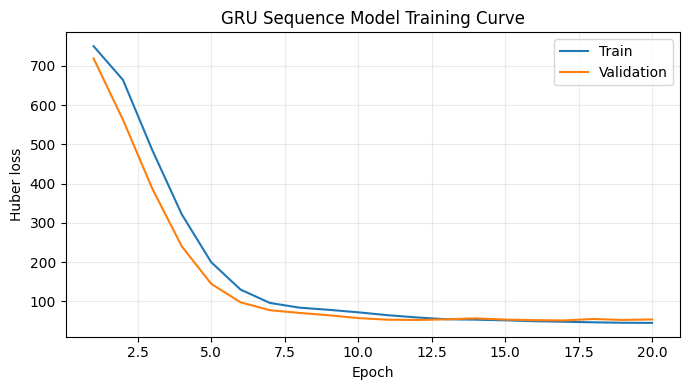

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(sequence_history_df["epoch"], sequence_history_df["train_loss"], label="Train")
plt.plot(sequence_history_df["epoch"], sequence_history_df["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Huber loss")
plt.title("GRU Sequence Model Training Curve")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


The GRU model keeps the temporal structure of each raw sensor window and therefore tests whether the sequence itself contains information that is lost when windows are summarized into handcrafted statistics. Its validation metrics are added to the same comparison table as the tabular models so that the added model complexity can be judged against the engineered-feature baselines.

In the current run, the GRU improves the validation MAE but does not clearly dominate the tree-based models across all metrics. This makes it useful as a deep-learning comparison model rather than as an automatic replacement for the handcrafted-feature pipeline.


# Model Comparison

The trained models are compared on the validation set using MAE, RMSE and the asymmetric C-MAPSS score. Lower values indicate better performance for all metrics.

In [27]:
model_results = pd.DataFrame([
    age_baseline_metrics,
    rf_metrics,
    xgb_metrics,
    gru_metrics
])

model_results = model_results[
    ["model", "MAE", "RMSE", "C-MAPSS_score"]
]

model_results


,model,MAE,RMSE,C-MAPSS_score
0,Age baseline,22.727165,27.942081,134393.008349
1,Random Forest,9.347447,12.789990,10533.922377
2,XGBoost,9.306013,12.669184,10083.464275
3,GRU sequence,8.274104,12.692048,13135.226213


In [28]:
# Ensure that all evaluated models are included in the comparison table.
assert set(model_results["model"]) == {
    "Age baseline",
    "Random Forest",
    "XGBoost",
    "GRU sequence"
}

# Ensure that all reported metric values are finite.
assert np.isfinite(model_results[["MAE", "RMSE", "C-MAPSS_score"]].to_numpy()).all()

# Ensure that all metrics are non-negative.
assert (model_results[["MAE", "RMSE", "C-MAPSS_score"]] >= 0).all().all()


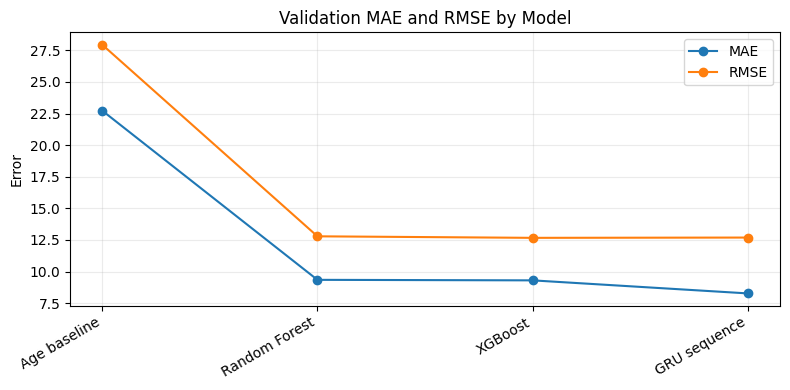

In [29]:
metric_plot_data = model_results.melt(
    id_vars="model",
    value_vars=["MAE", "RMSE"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(8, 4))

for metric in ["MAE", "RMSE"]:
    subset = metric_plot_data[metric_plot_data["metric"] == metric]
    plt.plot(
        subset["model"],
        subset["value"],
        marker="o",
        label=metric
    )

plt.ylabel("Error")
plt.title("Validation MAE and RMSE by Model")
plt.xticks(rotation=30, ha="right")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

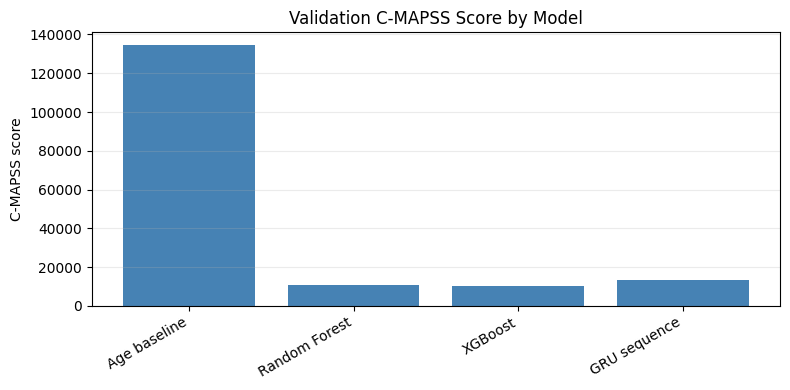

In [30]:
plt.figure(figsize=(8, 4))

plt.bar(
    model_results["model"],
    model_results["C-MAPSS_score"],
    color="steelblue"
)

plt.ylabel("C-MAPSS score")
plt.title("Validation C-MAPSS Score by Model")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

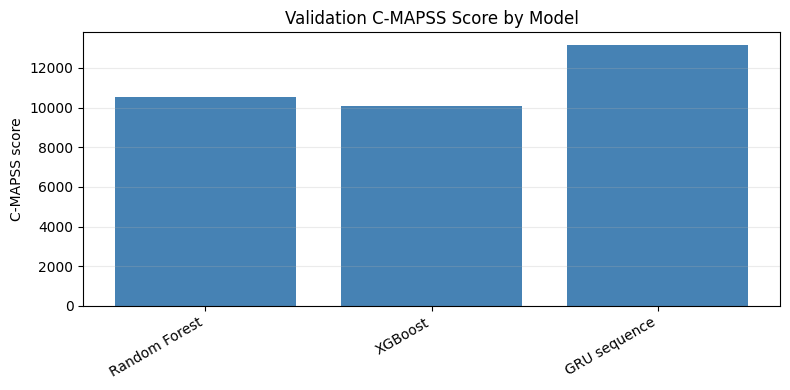

In [31]:
plot_results = model_results[
    model_results["model"] != "Age baseline"
]

plt.figure(figsize=(8, 4))

plt.bar(
    plot_results["model"],
    plot_results["C-MAPSS_score"],
    color="steelblue"
)

plt.ylabel("C-MAPSS score")
plt.title("Validation C-MAPSS Score by Model")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


The model comparison keeps one simple baseline, one bagging-based tree ensemble, one boosted-tree model and one sequence model. Random Forest represents a classical tree ensemble on handcrafted statistical window features, XGBoost is the main boosted-tree candidate, and the GRU tests whether directly modeling raw temporal windows improves predictive performance.

This comparison should be interpreted through both predictive performance and model complexity. A sequence model only earns its added implementation and tuning cost if it improves the relevant operational metric, especially the asymmetric C-MAPSS score. In the validation results, the GRU has the lowest MAE, but XGBoost remains strongest on RMSE and C-MAPSS score.


# Prediction Analysis

The validation predictions are analyzed in more detail to understand where models make errors. This includes predicted-vs-true plots, residual distributions and error behavior across the RUL range.

In [32]:
validation_predictions = {
    "Random Forest": rf_val_pred,
    "XGBoost": xgb_val_pred,
    "GRU sequence": gru_val_pred,
}


In [33]:
validation_prediction_df = val_window_metadata.copy()
validation_prediction_df["true_RUL"] = y_val_tabular.values

for model_name, predictions in validation_predictions.items():
    validation_prediction_df[f"pred_{model_name}"] = predictions
    validation_prediction_df[f"error_{model_name}"] = (
        predictions - validation_prediction_df["true_RUL"]
    )

validation_prediction_df.head()

,engine,start_cycle,end_cycle,true_RUL,pred_Random Forest,error_Random Forest,pred_XGBoost,error_XGBoost,pred_GRU sequence,error_GRU sequence
0,1,1.0,30.0,125,122.391833,-2.608167,122.004341,-2.995659,125.000000,0.000000
1,1,2.0,31.0,125,121.400929,-3.599071,120.672974,-4.327026,124.004547,-0.995453
2,1,3.0,32.0,125,119.495000,-5.505000,119.154335,-5.845665,125.000000,0.000000
3,1,4.0,33.0,125,120.139667,-4.860333,116.037529,-8.962471,125.000000,0.000000
4,1,5.0,34.0,125,118.812167,-6.187833,113.166229,-11.833771,123.655136,-1.344864


In [34]:
# Ensure that validation metadata and target values are aligned row-wise.
assert validation_prediction_df.shape[0] == y_val_tabular.shape[0]

# Ensure that each model produced one prediction for every validation window.
for model_name in validation_predictions:
    assert validation_prediction_df[f"pred_{model_name}"].notna().all()

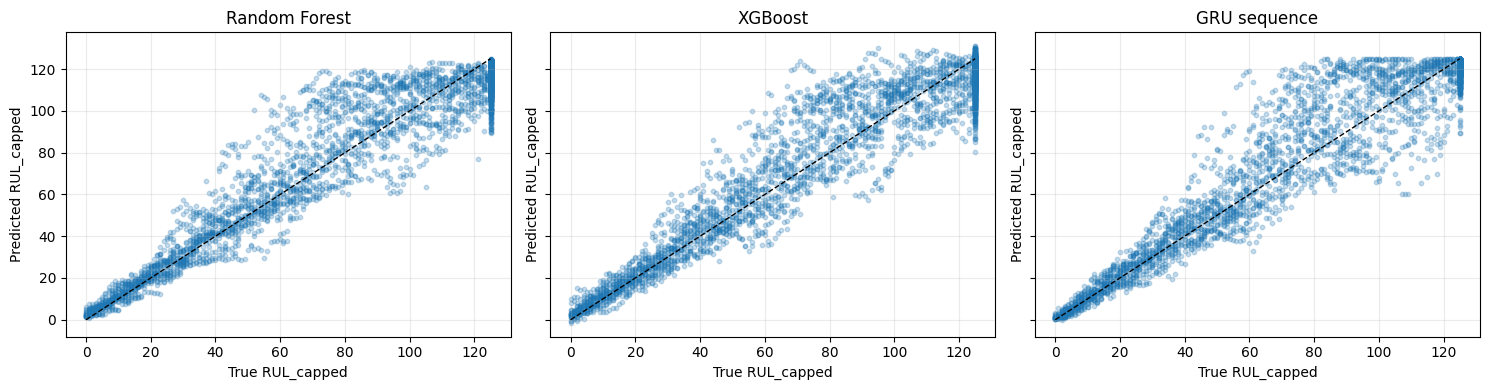

In [35]:
# Predicted vs. True Plot
fig, axes = plt.subplots(
    1,
    len(validation_predictions),
    figsize=(5 * len(validation_predictions), 4),
    sharex=True,
    sharey=True
)

if len(validation_predictions) == 1:
    axes = [axes]

for ax, (model_name, predictions) in zip(axes, validation_predictions.items()):
    ax.scatter(
        y_val_tabular,
        predictions,
        alpha=0.25,
        s=10
    )
    
    ax.plot(
        [0, RUL_CAP],
        [0, RUL_CAP],
        color="black",
        linestyle="--",
        linewidth=1
    )
    
    ax.set_title(model_name)
    ax.set_xlabel("True RUL_capped")
    ax.set_ylabel("Predicted RUL_capped")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

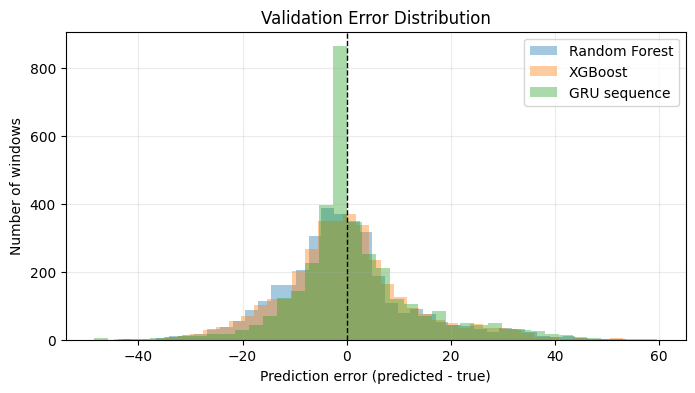

In [36]:
# Residual Distribution
plt.figure(figsize=(8, 4))

for model_name in validation_predictions:
    plt.hist(
        validation_prediction_df[f"error_{model_name}"],
        bins=40,
        alpha=0.4,
        label=model_name
    )

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction error (predicted - true)")
plt.ylabel("Number of windows")
plt.title("Validation Error Distribution")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

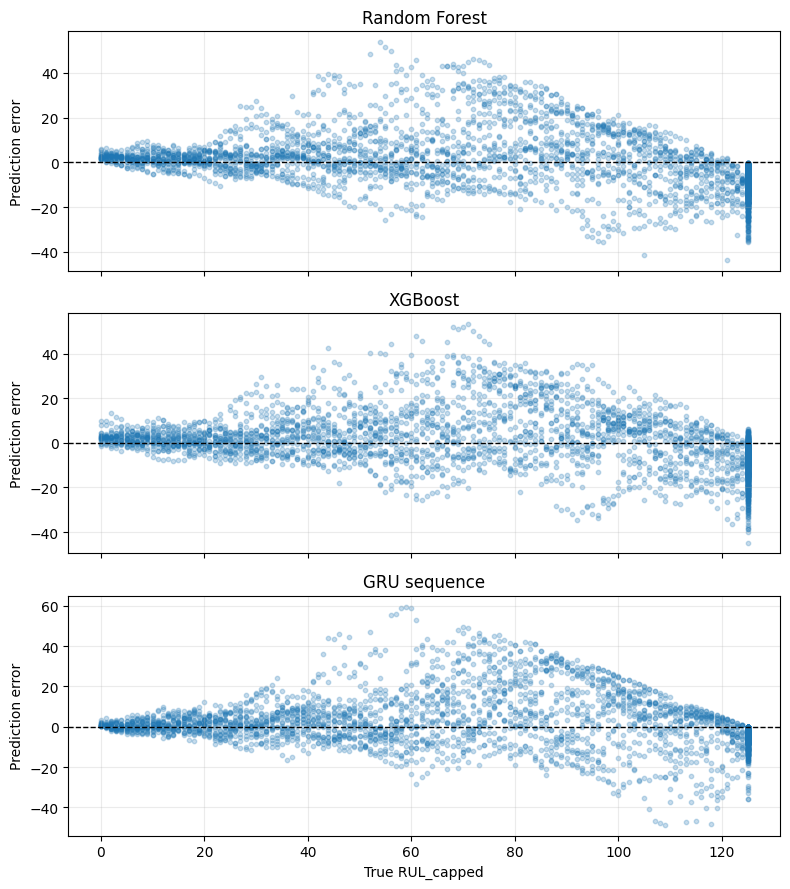

In [37]:
# Error vs. True RUL
fig, axes = plt.subplots(
    len(validation_predictions),
    1,
    figsize=(8, 3 * len(validation_predictions)),
    sharex=True
)

if len(validation_predictions) == 1:
    axes = [axes]

for ax, model_name in zip(axes, validation_predictions):
    ax.scatter(
        validation_prediction_df["true_RUL"],
        validation_prediction_df[f"error_{model_name}"],
        alpha=0.25,
        s=10
    )
    
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(model_name)
    ax.set_ylabel("Prediction error")
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("True RUL_capped")
plt.tight_layout()
plt.show()

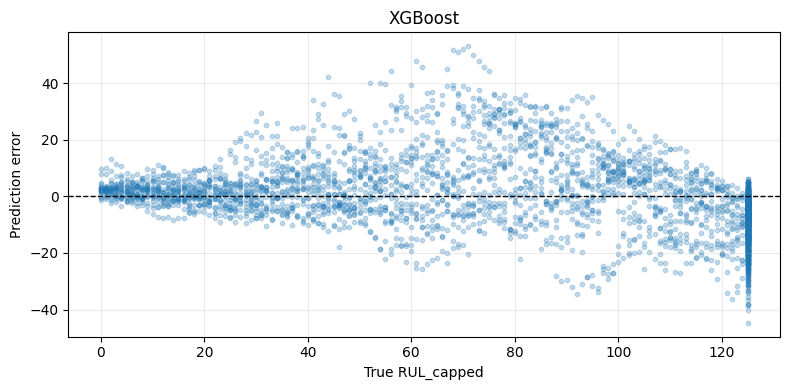

In [52]:
model_name = "XGBoost"

plt.figure(figsize=(8, 4))

plt.scatter(
    validation_prediction_df["true_RUL"],
    validation_prediction_df[f"error_{model_name}"],
    alpha=0.25,
    s=10
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title(model_name)
plt.xlabel("True RUL_capped")
plt.ylabel("Prediction error")
plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [38]:
# window-level predictions for single engines
selected_val_engines = (
    validation_prediction_df["engine"]
    .drop_duplicates()
    .head(3)
    .tolist()
)

selected_val_engines

[1, 5, 11]

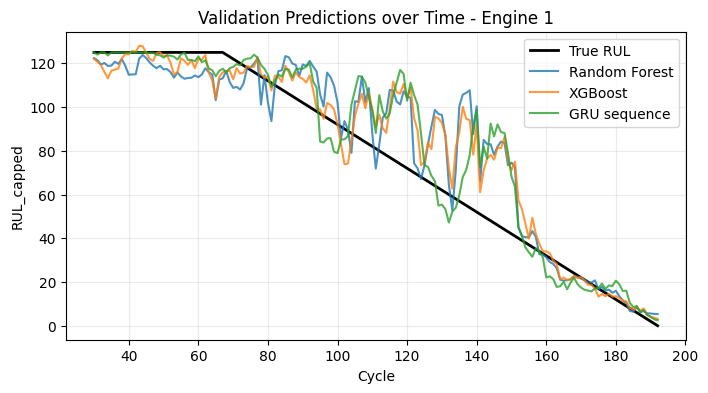

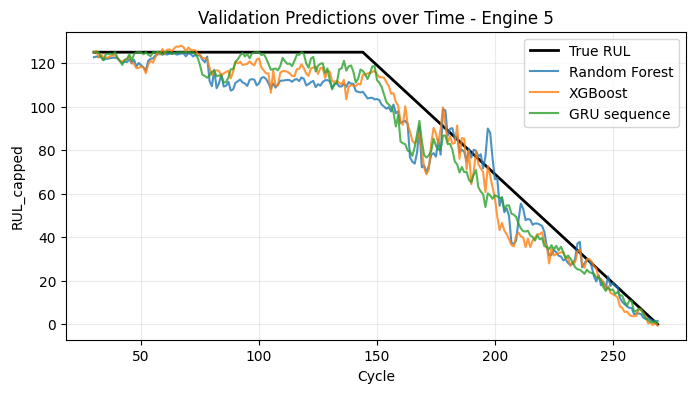

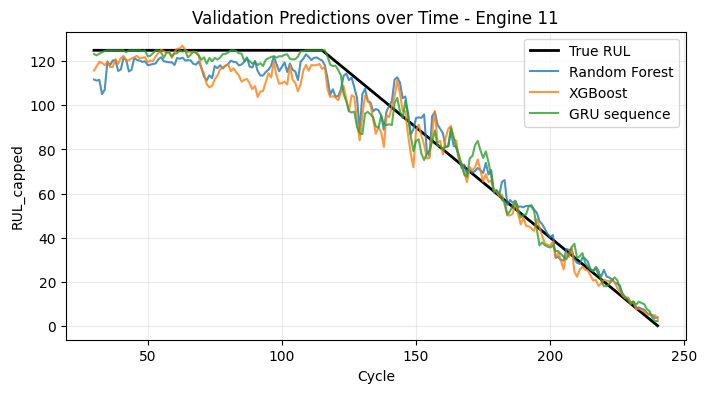

In [39]:
for engine in selected_val_engines:
    engine_predictions = validation_prediction_df[
        validation_prediction_df["engine"] == engine
    ].sort_values("end_cycle")

    plt.figure(figsize=(8, 4))

    plt.plot(
        engine_predictions["end_cycle"],
        engine_predictions["true_RUL"],
        label="True RUL",
        color="black",
        linewidth=2
    )

    for model_name in validation_predictions:
        plt.plot(
            engine_predictions["end_cycle"],
            engine_predictions[f"pred_{model_name}"],
            label=model_name,
            alpha=0.8
        )

    plt.xlabel("Cycle")
    plt.ylabel("RUL_capped")
    plt.title(f"Validation Predictions over Time - Engine {engine}")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

The prediction analysis shows how model errors are distributed across the validation windows. Predicted-vs-true plots indicate whether models systematically under- or overestimate RUL, while residual plots reveal the direction and spread of prediction errors.

Analyzing predictions over individual engine trajectories is especially important for predictive maintenance, because operational decisions are made over time rather than from isolated windows.

# Test Set Prediction Workflow

The trained models are applied to the test windows. Since the C-MAPSS test RUL file provides one true RUL value per engine at the final observed cycle, only the last generated window of each test engine is used for final test-level evaluation.

In [40]:
best_rmse_model = model_results.loc[
    model_results["RMSE"].idxmin(),
    "model"
]

best_score_model = model_results.loc[
    model_results["C-MAPSS_score"].idxmin(),
    "model"
]

best_rmse_model_name = best_rmse_model
best_score_model_name = best_score_model

best_rmse_model_name, best_score_model_name

('XGBoost', 'XGBoost')

In [41]:
trained_models = {
    "Age baseline": age_baseline_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
}

sequence_models = {
    "GRU sequence": gru_model,
}

best_rmse_model_object = (
    trained_models.get(best_rmse_model_name)
    or sequence_models.get(best_rmse_model_name)
)
best_score_model_object = (
    trained_models.get(best_score_model_name)
    or sequence_models.get(best_score_model_name)
)


In [42]:
test_prediction_df = test_window_metadata.copy()

test_prediction_df["pred_Age baseline"] = np.clip(
    age_baseline_model.predict(test_window_metadata[["end_cycle"]]),
    0,
    RUL_CAP
)

for model_name, model in trained_models.items():
    if model_name == "Age baseline":
        continue
    test_prediction_df[f"pred_{model_name}"] = model.predict(X_test_tabular)

for model_name, model in sequence_models.items():
    sequence_predictions = predict_sequence_model(
        model,
        X_test_sequence_tensor,
        device=device,
        batch_size=sequence_model_config["prediction_batch_size"],
    )
    test_prediction_df[f"pred_{model_name}"] = np.clip(
        sequence_predictions,
        0,
        RUL_CAP
    )

test_prediction_df.head()


,engine,start_cycle,end_cycle,pred_Age baseline,pred_Random Forest,pred_XGBoost,pred_GRU sequence
0,1,1.0,30.0,124.471989,110.630429,107.354034,116.045197
1,1,2.0,31.0,124.011215,108.408143,105.240509,115.033302
2,2,1.0,30.0,124.471989,116.059024,116.817451,121.084366
3,2,2.0,31.0,124.011215,116.410238,113.653427,120.168037
4,2,3.0,32.0,123.550442,96.995750,104.748955,117.379044


In [43]:
# Ensure that test metadata and test features contain the same number of windows.
assert test_prediction_df.shape[0] == X_test_tabular.shape[0]
assert test_prediction_df.shape[0] == X_test_sequence_tensor.shape[0]

# Ensure that every trained model produced finite test predictions.
for model_name in list(trained_models) + list(sequence_models):
    assert np.isfinite(test_prediction_df[f"pred_{model_name}"]).all()


In [44]:
# Select last window per engine
test_last_window_predictions = (
    test_prediction_df
    .sort_values(["engine", "end_cycle"])
    .groupby("engine")
    .tail(1)
    .reset_index(drop=True)
)

test_last_window_predictions.head()

,engine,start_cycle,end_cycle,pred_Age baseline,pred_Random Forest,pred_XGBoost,pred_GRU sequence
0,1,2.0,31.0,124.011215,108.408143,105.240509,115.033302
1,2,20.0,49.0,115.717294,117.339500,119.407448,125.000000
2,3,97.0,126.0,80.237741,41.365571,37.500763,47.030968
3,4,77.0,106.0,89.453209,101.335024,92.416725,92.396713
4,5,69.0,98.0,93.139396,98.513005,97.326164,117.261856


In [45]:
test_evaluation_df = test_last_window_predictions.merge(
    df_test_rul_summary,
    left_on="engine",
    right_on="engine",
    how="left"
)

test_evaluation_df.head()

,engine,start_cycle,end_cycle,pred_Age baseline,pred_Random Forest,pred_XGBoost,pred_GRU sequence,last_observed_cycle,RUL,estimated_failure_cycle
0,1,2.0,31.0,124.011215,108.408143,105.240509,115.033302,31,112,143
1,2,20.0,49.0,115.717294,117.339500,119.407448,125.000000,49,98,147
2,3,97.0,126.0,80.237741,41.365571,37.500763,47.030968,126,69,195
3,4,77.0,106.0,89.453209,101.335024,92.416725,92.396713,106,82,188
4,5,69.0,98.0,93.139396,98.513005,97.326164,117.261856,98,91,189


In [46]:
# Ensure that the selected last test window ends at the final observed cycle of each engine.
assert (
    test_evaluation_df["end_cycle"]
    == test_evaluation_df["last_observed_cycle"]
).all()

# Ensure that every test engine has one final prediction row.
assert test_evaluation_df["engine"].nunique() == df_test_rul_summary["engine"].nunique()

# Ensure that all test engines have an available true RUL value.
assert test_evaluation_df["RUL"].notna().all()

In [47]:
test_results = []

for model_name in list(trained_models) + list(sequence_models):
    predictions = test_evaluation_df[f"pred_{model_name}"]
    metrics = evaluate_predictions(
        test_evaluation_df["RUL"],
        predictions
    )
    metrics["model"] = model_name
    test_results.append(metrics)

test_results = pd.DataFrame(test_results)
test_results = test_results[["model", "MAE", "RMSE", "C-MAPSS_score"]]

test_results.sort_values("RMSE")


,model,MAE,RMSE,C-MAPSS_score
2,XGBoost,10.099241,13.412488,258.417089
1,Random Forest,10.684037,14.723485,347.937568
3,GRU sequence,12.688943,17.200758,738.344406
0,Age baseline,27.680196,33.389038,5617.460000


In [48]:
test_results.sort_values("C-MAPSS_score")

,model,MAE,RMSE,C-MAPSS_score
2,XGBoost,10.099241,13.412488,258.417089
1,Random Forest,10.684037,14.723485,347.937568
3,GRU sequence,12.688943,17.200758,738.344406
0,Age baseline,27.680196,33.389038,5617.460000


# Validation-to-Test Generalization Gap

The validation and test metrics are compared directly to inspect whether model performance transfers from the engine-wise validation split to the official C-MAPSS test set. A larger positive gap indicates that a model performs worse on the test engines than on validation windows.

In [49]:
generalization_gap_df = model_results.merge(
    test_results,
    on="model",
    suffixes=("_validation", "_test")
)

generalization_gap_df["MAE_gap"] = (
    generalization_gap_df["MAE_test"]
    - generalization_gap_df["MAE_validation"]
)
generalization_gap_df["RMSE_gap"] = (
    generalization_gap_df["RMSE_test"]
    - generalization_gap_df["RMSE_validation"]
)
generalization_gap_df["C-MAPSS_score_gap"] = (
    generalization_gap_df["C-MAPSS_score_test"]
    - generalization_gap_df["C-MAPSS_score_validation"]
)

generalization_gap_df = generalization_gap_df[[
    "model",
    "MAE_validation",
    "MAE_test",
    "MAE_gap",
    "RMSE_validation",
    "RMSE_test",
    "RMSE_gap",
    "C-MAPSS_score_validation",
    "C-MAPSS_score_test",
    "C-MAPSS_score_gap",
]]

generalization_gap_df.sort_values("RMSE_gap", ascending=False)


,model,MAE_validation,MAE_test,MAE_gap,RMSE_validation,RMSE_test,RMSE_gap,C-MAPSS_score_validation,C-MAPSS_score_test,C-MAPSS_score_gap
0,Age baseline,22.727165,27.680196,4.953031,27.942081,33.389038,5.446957,134393.008349,5617.460000,-128775.548349
3,GRU sequence,8.274104,12.688943,4.414839,12.692048,17.200758,4.508710,13135.226213,738.344406,-12396.881807
1,Random Forest,9.347447,10.684037,1.336590,12.789990,14.723485,1.933495,10533.922377,347.937568,-10185.984809
2,XGBoost,9.306013,10.099241,0.793228,12.669184,13.412488,0.743304,10083.464275,258.417089,-9825.047186


In [50]:
# Ensure that every evaluated model has both validation and test metrics.
assert set(generalization_gap_df["model"]) == set(model_results["model"])
assert set(generalization_gap_df["model"]) == set(test_results["model"])

# Ensure that gap values are finite.
gap_cols = ["MAE_gap", "RMSE_gap", "C-MAPSS_score_gap"]
assert np.isfinite(generalization_gap_df[gap_cols].to_numpy()).all()


The gap table highlights whether validation rankings are stable under the official test evaluation. In this run, the GRU improves the validation MAE but loses ground on the official test set, while XGBoost remains the strongest model across the final test metrics. This suggests that the GRU is more sensitive to the validation split, hyperparameters or trajectory differences between validation and test engines.


For the test set, only the final window per engine is evaluated because the provided RUL labels correspond to the last observed cycle of each test trajectory. This produces one prediction per test engine and allows direct comparison with the official C-MAPSS test RUL values.

In [51]:
PRIMARY_SELECTION_METRIC = "C-MAPSS_score"

validation_selected_model_name = model_results.loc[
    model_results[PRIMARY_SELECTION_METRIC].idxmin(),
    "model"
]

test_best_model_name = test_results.loc[
    test_results[PRIMARY_SELECTION_METRIC].idxmin(),
    "model"
]

print(f"Selected from validation: {validation_selected_model_name}")
print(f"Best on official test set: {test_best_model_name}")

Selected from validation: XGBoost
Best on official test set: XGBoost


# Model Training Takeaways

The final comparison keeps the modeling set intentionally compact: an age baseline that uses only window end cycle, Random Forest as a classical bagging-based tree ensemble, XGBoost as the boosted-tree main model and a GRU regressor trained directly on raw scaled sensor windows. This keeps the notebook readable while still covering the required comparison between handcrafted features and sequence learning.

The age baseline is more informative than a constant mean prediction because it tests whether sensor-based models improve beyond the degradation information already implied by engine age. The tree-based models and GRU therefore need to outperform this baseline to justify using multivariate sensor information.

On the validation set, the GRU sequence model achieved the lowest MAE, but XGBoost achieved the best RMSE and C-MAPSS score. This indicates that raw temporal windows contain useful predictive information, but the sequence model does not clearly outperform the engineered-feature tree models on the operationally important asymmetric score.

On the official test set, XGBoost achieved the best MAE, RMSE and C-MAPSS score. Random Forest remained competitive, while the GRU sequence model performed worse than both tree-based models but clearly better than the age baseline.

The validation-to-test comparison suggests that the GRU is more sensitive to generalization risk, hyperparameter choices or differences between validation and test trajectories. In this configuration, deep learning adds a useful comparison point, but the engineered-feature XGBoost pipeline remains the more reliable practical model.

Later notebooks can therefore continue to use XGBoost for SHAP explainability, uncertainty quantification and maintenance simulation, while the GRU result provides the required sequence-model comparison and a basis for discussing when deep learning earns its added complexity.


Preset for the thesis:

XGBoost is used as the primary model for explainability, uncertainty quantification and maintenance simulation because it achieved the best official test performance while remaining comparatively interpretable and computationally efficient. The GRU sequence model is included as a deep-learning baseline. It improves validation MAE, but its weaker RMSE, C-MAPSS score and test performance suggest stronger sensitivity to generalization risk and hyperparameter choices.
